
This notebook compares benchmark summaries and student-level results from the MT_recurso and MT2 datasets, including student aggregates and resource usage per line of code.

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

root = Path.cwd()
if not (root / "benchmark_results_MT_recurso").exists():
    root = Path("/home/pfpo/pls")


def count_code_lines(rel_path: str):
    path = root / rel_path
    if path.exists():
        with path.open("r", encoding="utf-8", errors="ignore") as handle:
            return sum(1 for _ in handle)
    return None


def load_summary(summary_path: Path, dataset_name: str) -> pd.DataFrame:
    with summary_path.open("r", encoding="utf-8") as handle:
        data = json.load(handle)

    timing = data.get("timing", {}) or {}
    memory = data.get("memory", {}) or {}
    errors = data.get("errors", {}) or {}
    return pd.DataFrame([
        {
            "dataset": dataset_name,
            "total_files": data.get("total_files"),
            "analyzed_files": data.get("analyzed_files"),
            "common_files_excluded": data.get("common_files_excluded"),
            "successful_runs": data.get("successful_runs"),
            "failed_runs": data.get("failed_runs"),
            "total_errors": errors.get("total"),
            "avg_time_ms": timing.get("avg_ms"),
            "median_time_ms": timing.get("median_ms"),
            "max_time_ms": timing.get("max_ms"),
            "avg_memory_mb": memory.get("avg_mb"),
            "max_memory_mb": memory.get("max_mb"),
        }
    ])


def load_results(csv_path: Path, dataset_name: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df["dataset"] = dataset_name
    df["student_id"] = pd.to_numeric(df["file"].str.split("/").str[1], errors="coerce")
    df["file_name"] = df["file"].str.split("/").str[-1]
    df["code_line_count"] = df["file"].apply(count_code_lines)

    numeric_cols = ["time_ms", "memory_mb", "total_errors"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    pass_columns = [
        col for col in df.columns
        if col.endswith("Analysis") or col in {"ClauseLengthAnalysis"}
    ]
    for col in pass_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    df["total_error_count"] = df[pass_columns].sum(axis=1)
    df["code_line_count"] = pd.to_numeric(df["code_line_count"], errors="coerce")
    return df


summary_paths = {
    "MT_recurso": root / "benchmark_results_MT_recurso" / "benchmark_summary.json",
    "MT2": root / "benchmark_results_MT2_2024" / "benchmark_summary.json",
}
results_paths = {
    "MT_recurso": root / "benchmark_results_MT_recurso" / "benchmark_results.csv",
    "MT2": root / "benchmark_results_MT2_2024" / "benchmark_results.csv",
}

summary_df = pd.concat([load_summary(summary_paths[name], name) for name in summary_paths], ignore_index=True)
results_df = pd.concat([load_results(results_paths[name], name) for name in results_paths], ignore_index=True)

summary_df

,dataset,total_files,analyzed_files,common_files_excluded,successful_runs,failed_runs,total_errors,avg_time_ms,median_time_ms,max_time_ms,avg_memory_mb,max_memory_mb
0,MT_recurso,717,606,111,606,0,1784,229.117216,222.725038,463.722300,0.035066,10.199219
1,MT2,2779,2450,329,2450,0,9153,232.302965,226.082888,416.442566,0.023190,11.945312


In [3]:
## 1. Compare MT_recurso and MT2 benchmark summaries

comparison = (
    results_df.groupby("dataset")
    .agg(
        files=("file", "count"),
        avg_time_ms=("time_ms", "mean"),
        median_time_ms=("time_ms", "median"),
        avg_memory_mb=("memory_mb", "mean"),
        max_memory_mb=("memory_mb", "max"),
        total_errors=("total_error_count", "sum"),
        avg_errors_per_file=("total_error_count", "mean"),
        success_ratio=("total_error_count", lambda s: (s == 0).mean()),
    )
    .reset_index()
)
comparison = comparison.merge(summary_df[["dataset", "total_files", "analyzed_files", "successful_runs", "failed_runs"]], on="dataset", how="left")
comparison

,dataset,files,avg_time_ms,median_time_ms,avg_memory_mb,max_memory_mb,total_errors,avg_errors_per_file,success_ratio,total_files,analyzed_files,successful_runs,failed_runs
0,MT2,2450,232.302976,226.083,0.023192,11.945,7535,3.075510,0.339184,2779,2450,2450,0
1,MT_recurso,606,229.117216,222.725,0.035069,10.199,1264,2.085809,0.410891,717,606,606,0


In [4]:
## 2. Aggregate statistics by student directory

student_agg = (
    results_df.groupby(["dataset", "student_id"])
    .agg(
        files=("file", "count"),
        avg_time_ms=("time_ms", "mean"),
        avg_memory_mb=("memory_mb", "mean"),
        total_errors=("total_error_count", "sum"),
        avg_errors_per_file=("total_error_count", "mean"),
        avg_code_lines=("code_line_count", "mean"),
        success_ratio=("total_error_count", lambda s: (s == 0).mean()),
    )
    .reset_index()
)
student_agg = student_agg.sort_values(["dataset", "avg_errors_per_file"], ascending=[True, True])
student_agg.head(15)

,dataset,student_id,files,avg_time_ms,avg_memory_mb,total_errors,avg_errors_per_file,avg_code_lines,success_ratio
27,MT2,28,4,195.704750,0.000000,0,0.000000,10.500000,1.000000
73,MT2,74,3,184.557333,0.000000,0,0.000000,11.000000,1.000000
97,MT2,98,4,185.444750,0.000000,0,0.000000,11.750000,1.000000
150,MT2,151,6,252.774667,0.000000,0,0.000000,15.833333,1.000000
152,MT2,153,7,239.357571,0.000000,0,0.000000,19.571429,1.000000
158,MT2,159,4,251.449000,0.000000,0,0.000000,10.500000,1.000000
163,MT2,164,2,192.683500,0.000000,0,0.000000,9.500000,1.000000
186,MT2,187,8,201.011375,0.000000,0,0.000000,15.250000,1.000000
223,MT2,224,12,252.481250,0.011750,0,0.000000,22.333333,1.000000
227,MT2,228,6,237.189667,0.000000,0,0.000000,11.666667,1.000000


In [5]:
## 3. Resource usage by number of code lines

results_df["time_per_line"] = results_df["time_ms"] / results_df["code_line_count"].replace(0, pd.NA)
results_df["memory_per_line"] = results_df["memory_mb"] / results_df["code_line_count"].replace(0, pd.NA)

corr_summary = (
    results_df.groupby("dataset")
    .apply(lambda g: g[["code_line_count", "time_ms", "memory_mb", "time_per_line", "memory_per_line"]].corr().loc["code_line_count", ["time_ms", "memory_mb"]])
    .unstack()
    .reset_index()
)
corr_summary.columns = ["dataset", "metric", "correlation"]
corr_summary

,dataset,metric,correlation
0,time_ms,MT2,0.237601
1,time_ms,MT_recurso,0.255106
2,memory_mb,MT2,-0.050857
3,memory_mb,MT_recurso,-0.051405


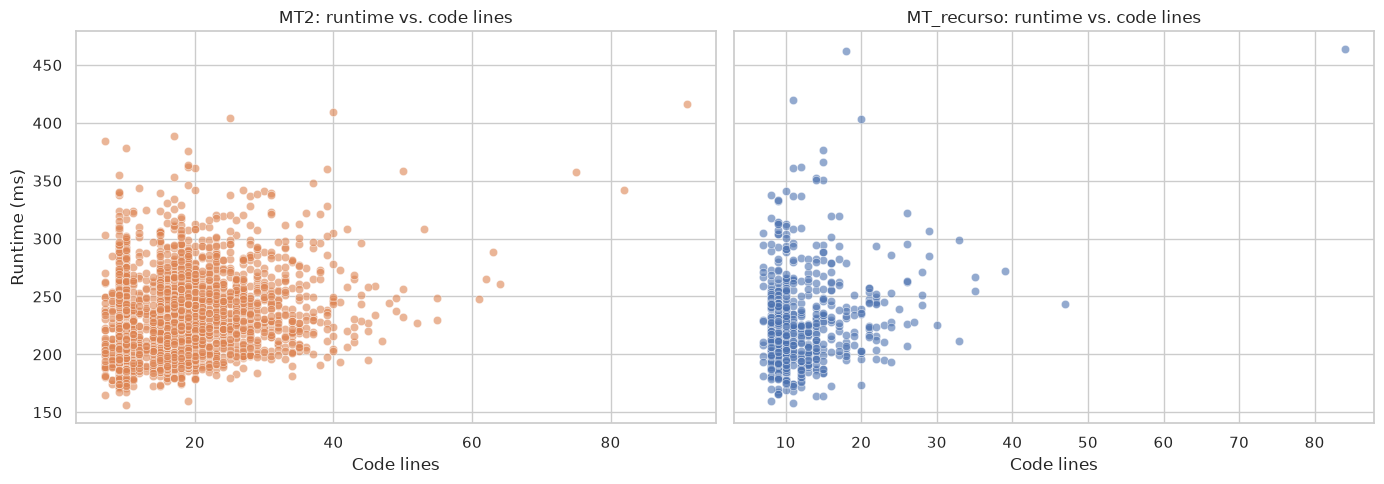

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (dataset, group) in zip(axes, results_df.groupby("dataset")):
    sns.scatterplot(data=group, x="code_line_count", y="time_ms", color="C0" if dataset == "MT_recurso" else "C1", alpha=0.6, ax=ax)
    ax.set_title(f"{dataset}: runtime vs. code lines")
    ax.set_xlabel("Code lines")
    ax.set_ylabel("Runtime (ms)")

plt.tight_layout()
plt.show()

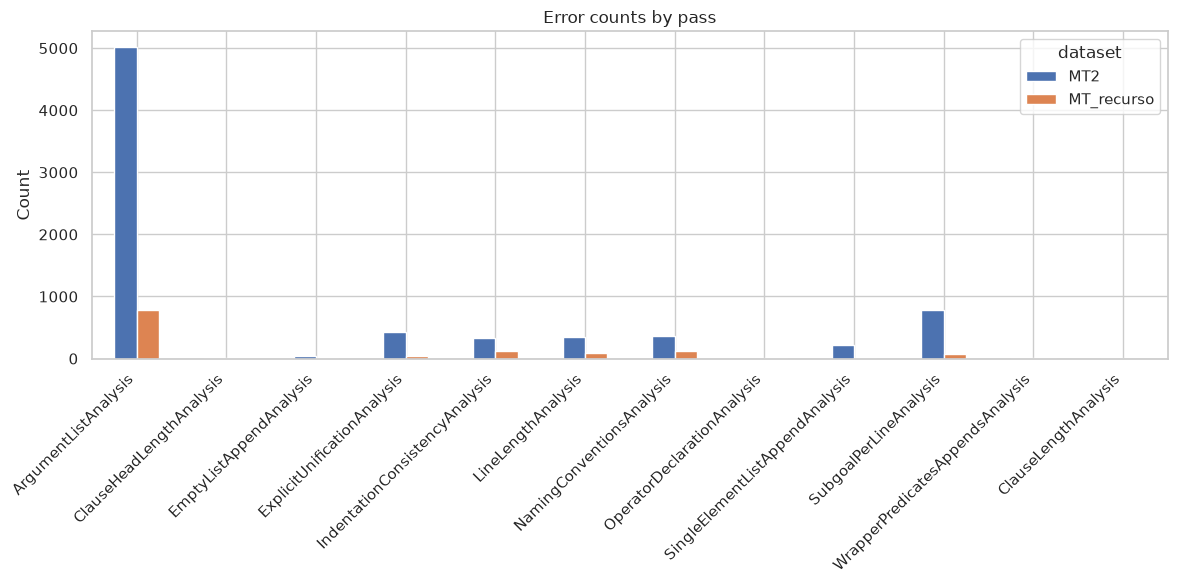

In [7]:
## 4. Error distributions and top error files

error_columns = [col for col in results_df.columns if col.endswith("Analysis") or col in {"ClauseLengthAnalysis"}]
error_totals = results_df.groupby("dataset")[error_columns].sum().T
error_totals.plot(kind="bar", figsize=(12, 6))
plt.title("Error counts by pass")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
# temp - retrieve top ArgumentListAnalysis files
top_argument_errors = (
    results_df[["dataset", "file", "ArgumentListAnalysis"]]
    .sort_values("ArgumentListAnalysis", ascending=False)
    .groupby("dataset")
    .head(10)
)

top_argument_errors

,dataset,file,ArgumentListAnalysis
1393,MT2,student_answers_MT2_2024/190/1.5.pl,34
638,MT2,student_answers_MT2_2024/101/3.1.pl,31
634,MT2,student_answers_MT2_2024/101/1.12.pl,30
1719,MT2,student_answers_MT2_2024/234/3.4.pl,28
1881,MT2,student_answers_MT2_2024/254/3.4.pl,27
2440,MT2,student_answers_MT2_2024/318/3.4.pl,26
1109,MT2,student_answers_MT2_2024/157/3.4.pl,25
725,MT2,student_answers_MT2_2024/112/1.12.pl,21
1260,MT2,student_answers_MT2_2024/175/1.5.pl,21
1110,MT2,student_answers_MT2_2024/157/3.5.pl,20


In [9]:
for dataset in sorted(results_df["dataset"].unique()):
    top_files = (
        results_df.loc[results_df["dataset"] == dataset]
        .groupby("file")["total_error_count"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )
    print(f"\n{dataset} top error files")
    print(top_files.to_string())


MT2 top error files
file
student_answers_MT2_2024/190/1.5.pl     51
student_answers_MT2_2024/101/3.1.pl     37
student_answers_MT2_2024/305/1.1.pl     35
student_answers_MT2_2024/101/1.12.pl    30
student_answers_MT2_2024/245/3.1.pl     29
student_answers_MT2_2024/234/3.4.pl     28
student_answers_MT2_2024/254/3.4.pl     28
student_answers_MT2_2024/318/3.4.pl     26
student_answers_MT2_2024/157/3.4.pl     25
student_answers_MT2_2024/232/3.2.pl     24

MT_recurso top error files
file
student_answers_MT-recurso/29/4.5.pl    56
student_answers_MT-recurso/26/5.1.pl    48
student_answers_MT-recurso/88/4.8.pl    28
student_answers_MT-recurso/69/5.1.pl    27
student_answers_MT-recurso/51/5.1.pl    25
student_answers_MT-recurso/80/5.1.pl    16
student_answers_MT-recurso/5/4.6.pl     15
student_answers_MT-recurso/32/4.6.pl    15
student_answers_MT-recurso/26/4.8.pl    15
student_answers_MT-recurso/6/4.5.pl     14


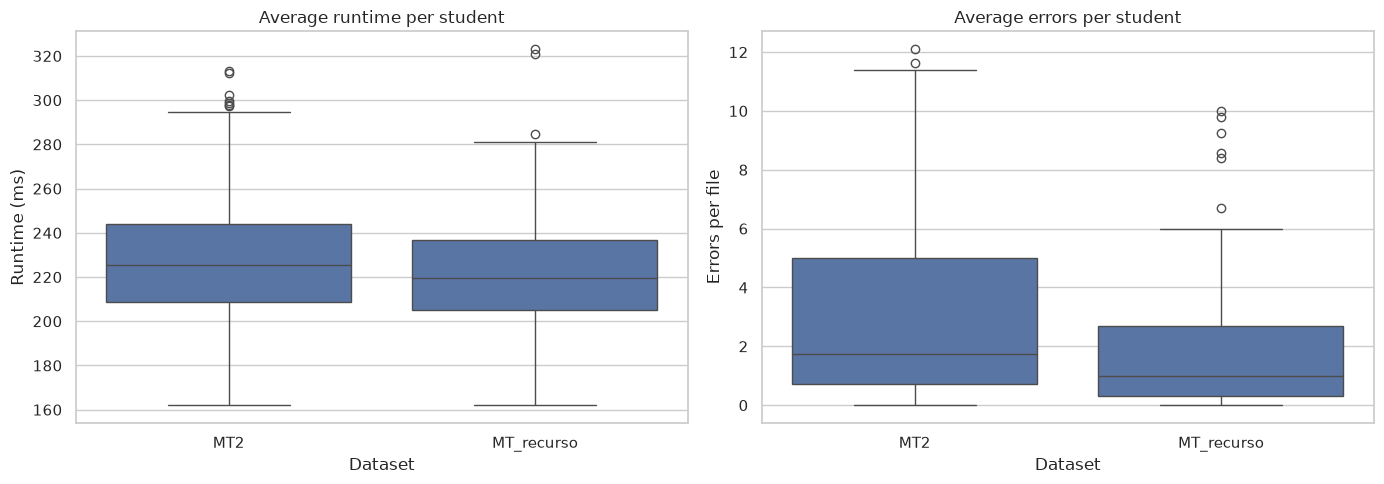

In [10]:
## 5. Visualize benchmark trends and student-level performance


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=student_agg, x="dataset", y="avg_time_ms", ax=axes[0])
axes[0].set_title("Average runtime per student")
axes[0].set_xlabel("Dataset")
axes[0].set_ylabel("Runtime (ms)")

sns.boxplot(data=student_agg, x="dataset", y="avg_errors_per_file", ax=axes[1])
axes[1].set_title("Average errors per student")
axes[1].set_xlabel("Dataset")
axes[1].set_ylabel("Errors per file")

plt.tight_layout()
plt.show()



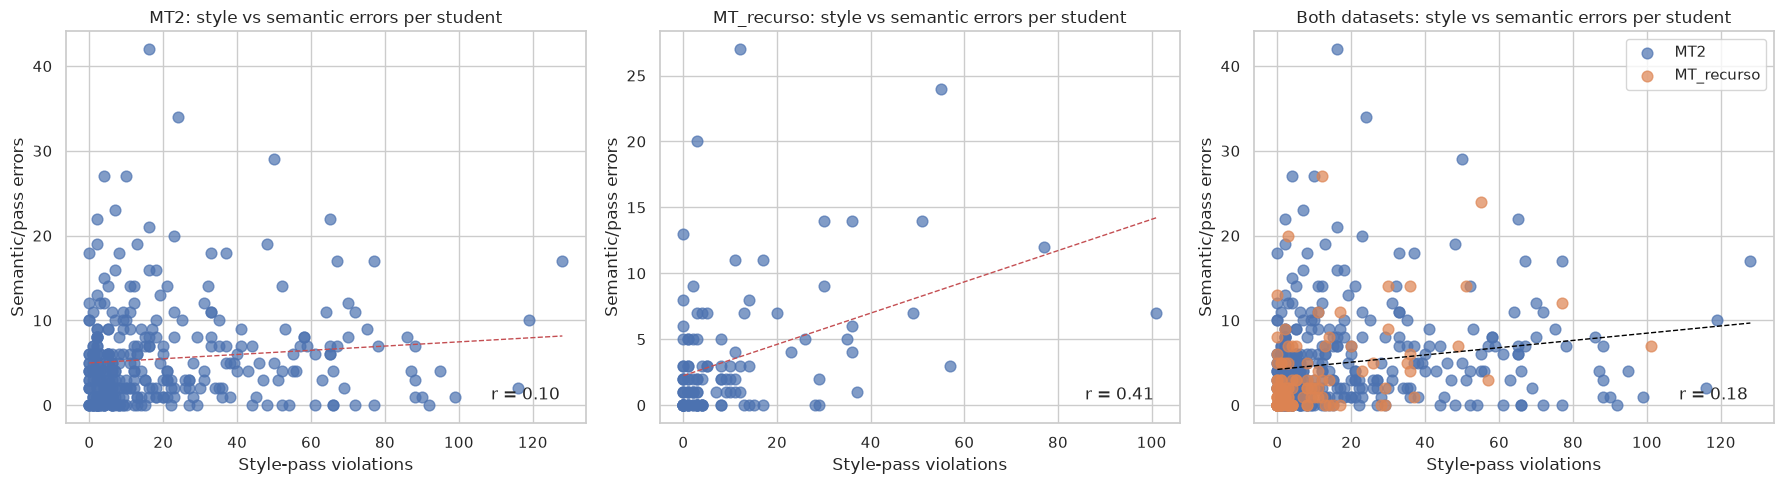

Correlation by dataset:
- MT2: r = 0.10
- MT_recurso: r = 0.41
- combined: r = 0.18


In [13]:
import numpy as np

style_passes = [
    name for name in [
        "IndentationConsistencyAnalysis",
        "LineLengthAnalysis",
        "ClauseHeadLengthAnalysis",
        "ClauseLengthAnalysis",
        "ArgumentListAnalysis",
        "SubgoalPerLineAnalysis",
        "ArgumentPlDocAnalysis",
        "NamingConventionsAnalysis",
    ]
    if name in results_df.columns
]

semantic_passes = [
    name for name in [
        "ExplicitUnificationAnalysis",
        "IsUseAnalysis",
        "WrapperPredicateAnalysis",
        "EmptyListAppendAnalysis",
        "SingleElementListAppendAnalysis",
        "NestedListAnalysis",
        "SyntaxErrorAnalysis",
        "UndifinedPredicate",
        "UnusedVariablePass"

    ]
    if name in results_df.columns
]

student_error_summary = (
    results_df.groupby(["dataset", "student_id"])[style_passes + semantic_passes]
    .sum()
    .reset_index()
    .fillna(0)
)
student_error_summary["style_total"] = student_error_summary[style_passes].sum(axis=1)
student_error_summary["semantic_total"] = student_error_summary[semantic_passes].sum(axis=1)
student_error_summary = student_error_summary.dropna(subset=["student_id"])
student_error_summary.head()


def corr_text(x, y):
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return "n/a"
    return f"r = {np.corrcoef(x, y)[0, 1]:.2f}"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (dataset, group) in zip(axes, student_error_summary.groupby("dataset")):
    x = group["style_total"]
    y = group["semantic_total"]
    ax.scatter(x, y, alpha=0.7, s=60)
    if len(x) >= 2 and np.std(x) > 0 and np.std(y) > 0:
        m, b = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 50)
        ax.plot(xs, m * xs + b, color="C3", linestyle="--", linewidth=1)
    ax.set_title(f"{dataset}: style vs semantic errors per student")
    ax.set_xlabel("Style-pass violations")
    ax.set_ylabel("Semantic/pass errors")
    ax.text(0.95, 0.05, corr_text(x, y), transform=ax.transAxes, ha="right", va="bottom")

combined = student_error_summary.copy()
ax = axes[2]
for dataset, group in combined.groupby("dataset"):
    ax.scatter(group["style_total"], group["semantic_total"], alpha=0.7, s=60, label=dataset)
if len(combined) >= 2 and np.std(combined["style_total"]) > 0 and np.std(combined["semantic_total"]) > 0:
    m, b = np.polyfit(combined["style_total"], combined["semantic_total"], 1)
    xs = np.linspace(combined["style_total"].min(), combined["style_total"].max(), 50)
    ax.plot(xs, m * xs + b, color="black", linestyle="--", linewidth=1)
ax.set_title("Both datasets: style vs semantic errors per student")
ax.set_xlabel("Style-pass violations")
ax.set_ylabel("Semantic/pass errors")
ax.text(0.95, 0.05, corr_text(combined["style_total"], combined["semantic_total"]), transform=ax.transAxes, ha="right", va="bottom")
ax.legend()

plt.tight_layout()
plt.show()

print("Correlation by dataset:")
for dataset, group in student_error_summary.groupby("dataset"):
    print(f"- {dataset}: {corr_text(group['style_total'], group['semantic_total'])}")
print(f"- combined: {corr_text(combined['style_total'], combined['semantic_total'])}")

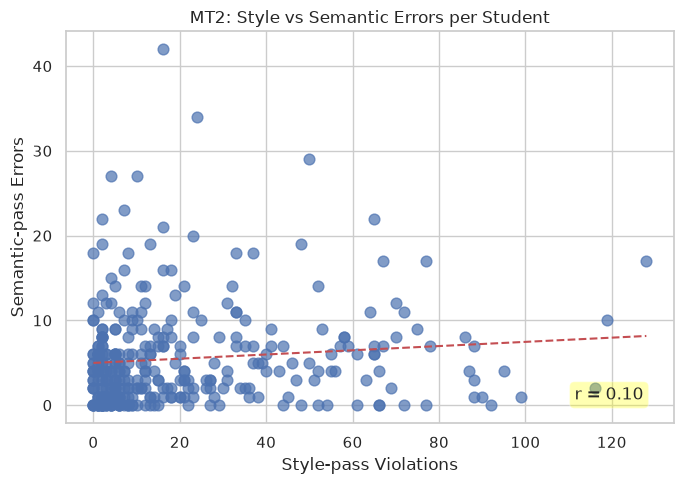

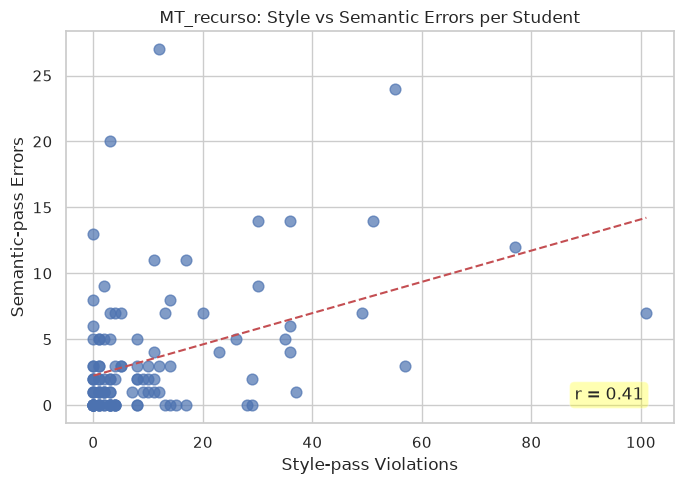

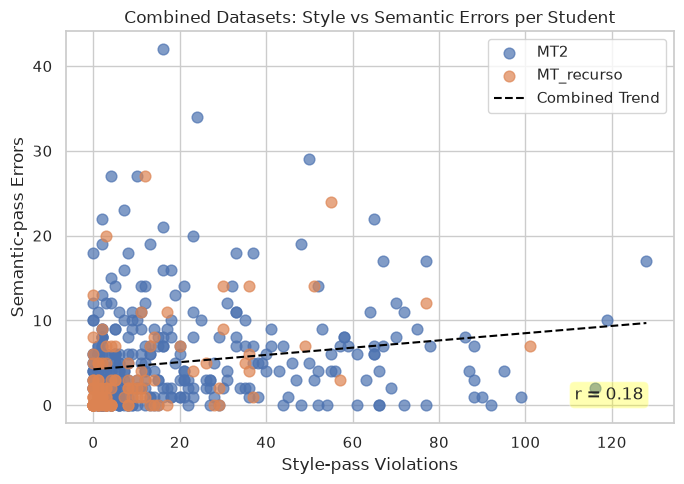

Correlation Summary:
- MT2: r = 0.10
- MT_recurso: r = 0.41
- Combined: r = 0.18


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Passes (Exactly matching your lists) ---
style_passes = [
    name for name in [
        "IndentationConsistencyAnalysis", "LineLengthAnalysis", "ClauseHeadLengthAnalysis",
        "ClauseLengthAnalysis", "ArgumentListAnalysis", "SubgoalPerLineAnalysis",
        "ArgumentPlDocAnalysis", "NamingConventionsAnalysis"
    ] if name in results_df.columns
]

semantic_passes = [
    name for name in [
        "ExplicitUnificationAnalysis", "IsUseAnalysis", "WrapperPredicateAnalysis",
        "EmptyListAppendAnalysis", "SingleElementListAppendAnalysis", "NestedListAnalysis",
        "SyntaxErrorAnalysis", "UndifinedPredicate", "UnusedVariablePass"
    ] if name in results_df.columns
]

# --- 2. Aggregate per Student ---
student_error_summary = (
    results_df.groupby(["dataset", "student_id"])[style_passes + semantic_passes]
    .sum().reset_index().fillna(0)
)
student_error_summary["style_total"] = student_error_summary[style_passes].sum(axis=1)
student_error_summary["semantic_total"] = student_error_summary[semantic_passes].sum(axis=1)
student_error_summary = student_error_summary.dropna(subset=["student_id"])

def corr_text(x, y):
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return "n/a"
    return f"r = {np.corrcoef(x, y)[0, 1]:.2f}"

# --- 3. Generate SEPARATE Plots for Each Dataset ---
for dataset, group in student_error_summary.groupby("dataset"):
    plt.figure(figsize=(7, 5))
    x = group["style_total"]
    y = group["semantic_total"]
    
    # Scatter plot configuration
    plt.scatter(x, y, alpha=0.7, s=60, color="C0")
    
    # Fit line calculation
    if len(x) >= 2 and np.std(x) > 0 and np.std(y) > 0:
        m, b = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 50)
        plt.plot(xs, m * xs + b, color="C3", linestyle="--", linewidth=1.5, label="Trendline")
        
    plt.title(f"{dataset}: Style vs Semantic Errors per Student")
    plt.xlabel("Style-pass Violations")
    plt.ylabel("Semantic-pass Errors")
    
    # Place correlation text box cleanly
    plt.text(0.95, 0.05, corr_text(x, y), transform=plt.gca().transAxes, 
             ha="right", va="bottom", bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3))
    
    plt.tight_layout()
    # Save the file automatically for your LaTeX report
    safe_name = dataset.replace(" ", "_").lower()
    plt.savefig(f"style_vs_semantic_{safe_name}.pdf", bbox_inches='tight')
    plt.show()

# --- 4. Generate Combined Dataset Plot ---
plt.figure(figsize=(7, 5))
combined = student_error_summary.copy()
for dataset, group in combined.groupby("dataset"):
    plt.scatter(group["style_total"], group["semantic_total"], alpha=0.7, s=60, label=dataset)

if len(combined) >= 2 and np.std(combined["style_total"]) > 0 and np.std(combined["semantic_total"]) > 0:
    m, b = np.polyfit(combined["style_total"], combined["semantic_total"], 1)
    xs = np.linspace(combined["style_total"].min(), combined["style_total"].max(), 50)
    plt.plot(xs, m * xs + b, color="black", linestyle="--", linewidth=1.5, label="Combined Trend")

plt.title("Combined Datasets: Style vs Semantic Errors per Student")
plt.xlabel("Style-pass Violations")
plt.ylabel("Semantic-pass Errors")
plt.text(0.95, 0.05, corr_text(combined["style_total"], combined["semantic_total"]), 
         transform=plt.gca().transAxes, ha="right", va="bottom", 
         bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3))
plt.legend()
plt.tight_layout()
plt.savefig("style_vs_semantic_combined.pdf", bbox_inches='tight')
plt.show()

# Print console summary
print("Correlation Summary:")
for dataset, group in student_error_summary.groupby("dataset"):
    print(f"- {dataset}: {corr_text(group['style_total'], group['semantic_total'])}")
print(f"- Combined: {corr_text(combined['style_total'], combined['semantic_total'])}")